In [1]:
!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
adult = fetch_ucirepo(id=2)

X = adult.data.features.copy()
y = adult.data.targets.copy()

df = pd.concat([X, y], axis=1)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset loaded successfully!
Shape: (48842, 15)

First 5 rows:
   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  Un

In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
print(df.describe())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (48842, 15)

Column Names:
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

Data Types:
age               int64
workclass           str
fnlwgt            int64
education           str
education-num     int64
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
native-country      str
income              str
dtype: object

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       47879 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-nul

In [5]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percent": missing_percent.round(2)
})

print(missing_table[missing_table["Missing Count"] > 0])

                Missing Count  Missing Percent
workclass                2799             5.73
occupation               2809             5.75
native-country            857             1.75


In [6]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


C:\Users\vamsh\AppData\Local\Temp\ipykernel_23660\1848118353.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


In [7]:
print("Duplicates before:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

print("Duplicates after:", df.duplicated().sum())

Duplicates before: 29
Duplicates after: 0


In [8]:
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

print("Categorical values standardized successfully.")
print(df.head())

Categorical values standardized successfully.
   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United-States  <=50

C:\Users\vamsh\AppData\Local\Temp\ipykernel_23660\2021473167.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [9]:
numeric_cols = df.select_dtypes(include=np.number).columns

print("Minimum values of numerical columns:")
print(df[numeric_cols].min())

print("\nNegative Age:", (df["age"] < 0).sum())
print("Negative Hours-per-week:", (df["hours-per-week"] < 0).sum())
print("Negative Capital-gain:", (df["capital-gain"] < 0).sum())
print("Negative Capital-loss:", (df["capital-loss"] < 0).sum())

Minimum values of numerical columns:
age                  17
fnlwgt            12285
education-num         1
capital-gain          0
capital-loss          0
hours-per-week        1
dtype: int64

Negative Age: 0
Negative Hours-per-week: 0
Negative Capital-gain: 0
Negative Capital-loss: 0


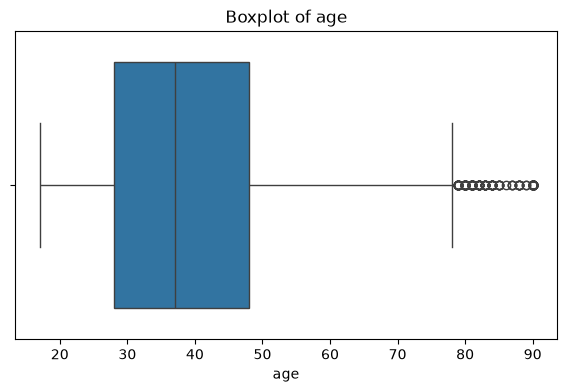

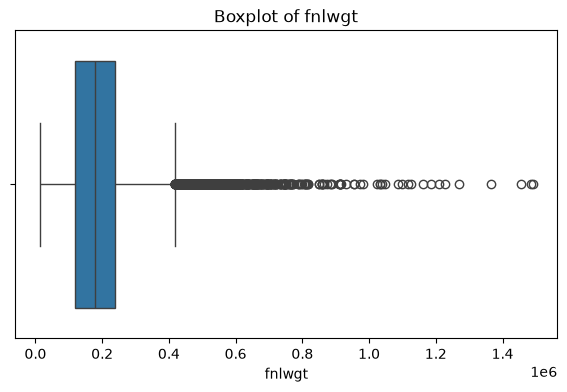

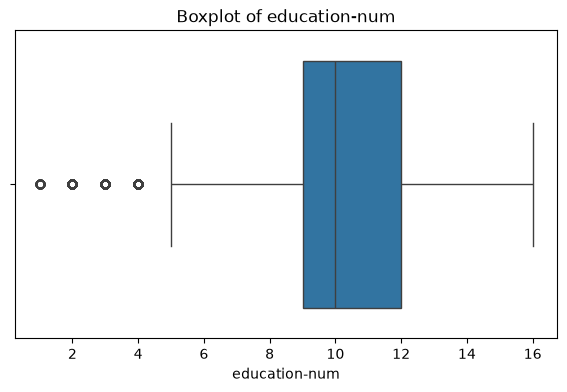

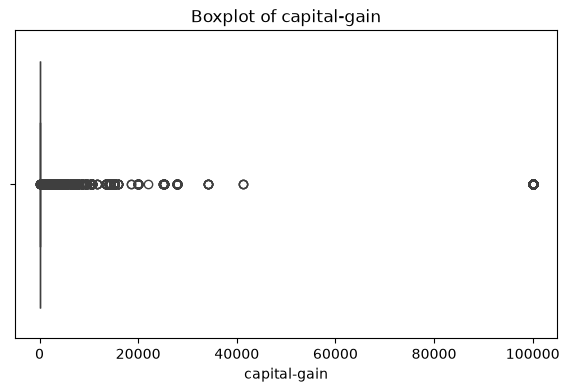

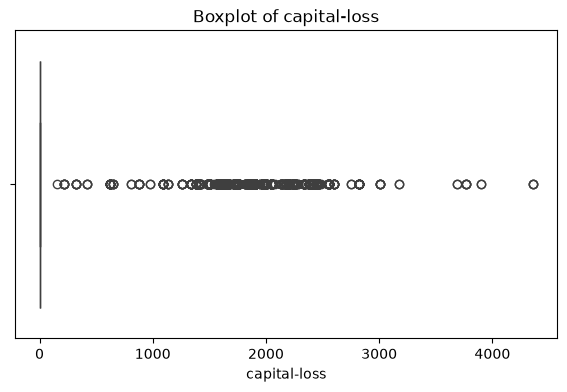

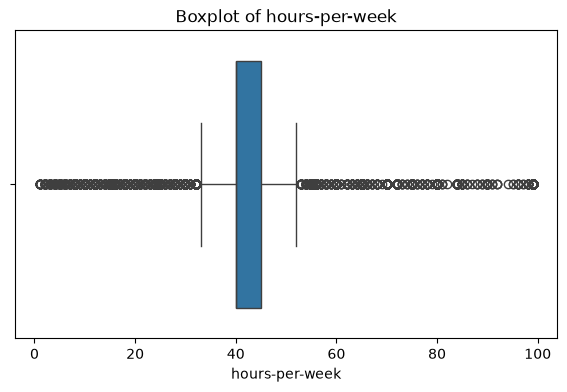

In [10]:
numeric_for_plot = [
    "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

for col in numeric_for_plot:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=df[col])
    plt.title("Boxplot of " + col)
    plt.show()

In [11]:
def iqr_outlier_count(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = ((data[column] < lower) | (data[column] > upper)).sum()

    return count, lower, upper


for col in numeric_for_plot:
    count, lower, upper = iqr_outlier_count(df, col)

    print(
        col,
        "| Outliers:", count,
        "| Lower:", round(lower, 2),
        "| Upper:", round(upper, 2)
    )

age | Outliers: 215 | Lower: -2.0 | Upper: 78.0
fnlwgt | Outliers: 1453 | Lower: -62542.5 | Upper: 417717.5
education-num | Outliers: 1789 | Lower: 4.5 | Upper: 16.5
capital-gain | Outliers: 4035 | Lower: 0.0 | Upper: 0.0
capital-loss | Outliers: 2282 | Lower: 0.0 | Upper: 0.0
hours-per-week | Outliers: 13489 | Lower: 32.5 | Upper: 52.5


In [12]:
X = df.drop(columns=["income"])
y = df["income"].str.strip()

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget values:")
print(y.value_counts())

Features shape: (48813, 14)
Target shape: (48813,)

Target values:
income
<=50K     24698
<=50K.    12430
>50K       7839
>50K.      3846
Name: count, dtype: int64


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (39050, 14)
Testing data: (9763, 14)


In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = X.select_dtypes(include="object").columns
numerical_features = X.select_dtypes(include=np.number).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        ), categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (39050, 97)
Processed testing shape: (9763, 97)


C:\Users\vamsh\AppData\Local\Temp\ipykernel_23660\1535957955.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include="object").columns


In [15]:
print("FINAL DATA QUALITY CHECK")
print("------------------------")

print("Rows:", len(df))
print("Columns:", df.shape[1])

print("Total missing values:", df.isnull().sum().sum())

print("Duplicate rows:", df.duplicated().sum())

print("\nFinal dataset:")
print(df.head())

FINAL DATA QUALITY CHECK
------------------------
Rows: 48813
Columns: 15
Total missing values: 0
Duplicate rows: 0

Final dataset:
   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week nati

In [16]:
df.to_csv("adult_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")
print("File name: adult_cleaned.csv")

Cleaned dataset saved successfully!
File name: adult_cleaned.csv
